# LangGraph: Agents, Tools, Memory & Streaming

**Self-learning notebook** — build stateful LLM agents step by step with [LangGraph](https://langchain-ai.github.io/langgraph/).

## What you will learn

| Topic | Idea |
|-------|------|
| **StateGraph** | Nodes + edges orchestrate an agent; shared `State` holds conversation history |
| **Tool calling** | LLM decides when to search the web or run Python functions |
| **ReAct loop** | `tools → LLM → tools → …` until the model has enough context to answer |
| **Checkpoints** | `MemorySaver` + `thread_id` give multi-turn memory |
| **Streaming** | `stream`, `stream_mode`, and `astream_events` for responsive UIs |

## Prerequisites

- Python 3.10+
- API keys (Colab: **Settings → Secrets**):
  - `GROQ_API_KEY` — primary LLM (Groq)
  - `HF_TOKEN` — optional Hugging Face router demo
  - `TAVILY_API_KEY` — web search tool

> **Run cells top-to-bottom.** Later sections rebuild the graph with new capabilities.

In [1]:
# Setup: install dependencies for this section (run once per session)
!pip install langgraph

## 1. Install LangGraph

LangGraph sits on top of LangChain Core and adds **graph-based orchestration** for agents (cycles, branching, persistence).

In [2]:
# Core LangGraph imports for building stateful agent graphs
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

## 2. Define Graph State

Every LangGraph workflow needs a **state schema**. Here we keep a list of chat `messages`.

- `TypedDict` declares the shape of state passed between nodes.
- `Annotated[list, add_messages]` is a **reducer**: new messages are *appended*, not overwritten.

In [3]:
class State(TypedDict):
    # Shared graph state: message history accumulates via add_messages reducer
    messages: Annotated[list, add_messages]


In [4]:
# Optional: load secrets from a local .env file (works outside Colab)
import os
from dotenv import load_dotenv
load_dotenv()

False

## 3. Environment & API Keys

Load secrets from `.env` locally, or from Colab **Secrets** in the cloud notebook.

In [5]:
# Colab-only: fetch secrets from Notebook secrets (Settings > Secrets)
from google.colab import userdata

In [6]:
# Hugging Face token — used later for HF Inference Router
HF_TOKEN= userdata.get('HF_TOKEN')

In [7]:
!pip install langchain_groq langchain sentence-transformers huggingface-hub langchain_openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.3 MB/s eta 0:00:00


## 4. Configure the LLM

We use **Groq** (`ChatGroq`) for fast inference. An alternative **Hugging Face** router setup is shown for comparison — pick one primary LLM for the exercises.

In [8]:
# Groq provides fast hosted inference; init_chat_model is the generic LC entry point
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

In [9]:
# Store Groq API key from Colab secrets
GROQ_API_KEY= userdata.get('GROQ_API_KEY')

In [10]:
# Primary LLM for this notebook — Llama 3.3 70B on Groq
llm  = ChatGroq(model="llama-3.3-70b-versatile", api_key = GROQ_API_KEY)

In [11]:
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7a81118305f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a81116dd370>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [12]:
# Alternative: call Hugging Face models via the OpenAI-compatible router
from langchain_openai import ChatOpenAI

In [13]:
# Swap with ChatGroq above if you prefer HF-hosted Llama 3 8B
llm_hf  = ChatOpenAI(
    model="meta-llama/Meta-Llama-3-8B-Instruct",
    api_key = HF_TOKEN,
    base_url="https://router.huggingface.co/v1",
    temperature=0.7,
    streaming=True)

## 5. Part A — Minimal Chatbot Graph

The simplest LangGraph agent:

```
START → chatbot (LLM) → END
```

1. **`chatbot` node** — reads `state["messages"]`, calls the LLM, returns the reply.
2. **`StateGraph.compile()`** — produces a runnable graph object.

In [14]:
def chatbot(state: State):
    """Graph node: pass conversation history to the LLM and append its reply."""
    return {"messages": [llm.invoke(state["messages"])]}


In [15]:
# 1. Create a StateGraph typed with our State schema
graph_builder = StateGraph(State)

# 2. Register nodes (functions that read/update state)
graph_builder.add_node("llmchatbot", chatbot)

# 3. Wire edges: START -> chatbot -> END
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# 4. Compile into a runnable graph
graph = graph_builder.compile()


### 5.1 Visualize & Run the Graph

- `graph.invoke(...)` — run to completion, return final state.
- Inspect `response["messages"][-1].content` for the assistant's last reply.

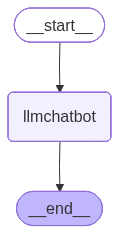

In [16]:
# Visualize the graph topology (requires graphviz/pygraphviz in some environments)
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [17]:
# invoke() runs the full graph synchronously and returns final state
response=graph.invoke({"messages":"Hi"})

In [18]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='0fd246fc-43e3-4a04-81c3-0d5cbf8bf817'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.050765631, 'completion_tokens_details': None, 'prompt_time': 0.004914488, 'prompt_tokens_details': None, 'queue_time': 0.295610152, 'total_time': 0.055680119}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f13d9-24d3-7340-927e-87584b160f52-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [19]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

### 5.2 Stream Node-by-Node Output

`graph.stream()` emits events as each node finishes — the pattern used in chat UIs to show progress.

In [20]:
# stream() yields partial state after each node executes — useful for UX/progress
for event in graph.stream({"messages":"Hi How are you?"}):
  for value in event.values():
    print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?


## 6. Part B — Tool-Calling Agent

Agents become useful when the LLM can **act** — search the web, call APIs, or run code.

We add two tools:
1. **TavilySearch** — live web search
2. **`multiply`** — custom Python function (schema from type hints + docstring)

In [21]:
!pip install langchain_tavily

In [22]:
from langchain_tavily import TavilySearch

In [23]:
# Tavily provides a web-search tool for retrieval-augmented agents
TAVILY_API_KEY= userdata.get('TAVILY_API_KEY')

In [24]:
# Smoke-test the search tool before wiring it into the graph
tool=TavilySearch(max_results=2, tavily_api_key=TAVILY_API_KEY )
tool.invoke("What is langgraph?")


{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [25]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Docstrings become the tool description the LLM reads when deciding whether to call it.

    Args:
        a (int): first number
        b (int): second number

    Returns:
        int: product of a and b
    """
    return a * b


In [26]:
# Agent toolbelt: external search + local Python function
tools=[tool,multiply]

### 6.1 Bind Tools to the LLM

`llm.bind_tools(tools)` attaches tool definitions so the model can emit structured `tool_call` messages.

In [27]:
# bind_tools() teaches the LLM which tools exist and how to request them
llm_with_tool=llm.bind_tools(tools)

In [28]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7a81118305f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a81116dd370>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. 

### 6.2 Agent Graph (single pass — no tool loop)

```
START → tool_calling_llm ⇄ tools_condition → END or tools
```

`tools_condition` is a prebuilt router:
- If the LLM returned **tool calls** → go to `ToolNode`
- Otherwise → **END**

⚠️ **Missing the `tools → LLM` edge** means the model never sees tool results. Try the next section to fix that.

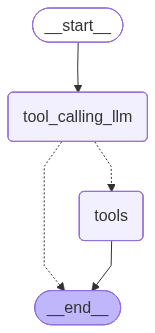

In [39]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


def tool_calling_llm(state: State):
    """LLM node that may emit tool_call messages instead of a final answer."""
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))  # executes tool calls

builder.add_edge(START, "tool_calling_llm")
# tools_condition routes to ToolNode if the LLM requested tools, else END
builder.add_conditional_edges("tool_calling_llm", tools_condition)

graph = builder.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


### 6.3 Thread Configuration

`config = {"configurable": {"thread_id": "123"}}` labels a conversation thread. Required once we add checkpointing.

In [ ]:
# thread_id groups checkpoints — same id = same conversation thread
config={"configurable":{"thread_id":"123"}}

### 6.4 Exercise — Observe Tool Calls

Run queries that trigger search and/or math. Use `pretty_print()` on messages to see **Human → AI → Tool → AI** turns.

In [30]:
response=graph.invoke({"messages":"What is the recent ai news"}, config=config)

In [31]:
response["messages"][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/janakirammsv/2026/06/29/prompts-are-the-new-malware-as-enterprise-ai-defenses-fall-behind/", "title": "Prompts Are The New Malware As Enterprise AI Defenses Fall Behind - Forbes", "score": 0.57894874, "published_date": "Mon, 29 Jun 2026 00:00:00 GMT", "content": "# Prompts Are The New Malware As Enterprise AI Defenses Fall Behind. A recent CrowdStrike report reveals prompt injection attacks impacted over 90 organizations in 2025, with prompts now functioning as malware to steal credentials and cryptocurrency. AI-enabled adversary operations surged 89% year-over-year, and 82% of intrusions involved no traditional malicious code, as enterprises deploy AI agents with extensive access. Prompt injection remains the top vulnerability on the OWASP Top 10 for LLMs, stemming from models\' inability to differentiate developer instructions from retrieved conten

In [32]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9t3zr5g8f)
 Call ID: 9t3zr5g8f
  Args:
    query: recent ai news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/janakirammsv/2026/06/29/prompts-are-the-new-malware-as-enterprise-ai-defenses-fall-behind/", "title": "Prompts Are The New Malware As Enterprise AI Defenses Fall Behind - Forbes", "score": 0.57894874, "published_date": "Mon, 29 Jun 2026 00:00:00 GMT", "content": "# Prompts Are The New Malware As Enterprise AI Defenses Fall Behind. A recent CrowdStrike report reveals prompt injection attacks impacted over 90 organizations in 2025, with pr

In [33]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9t3zr5g8f)
 Call ID: 9t3zr5g8f
  Args:
    query: recent ai news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/janakirammsv/2026/06/29/prompts-are-the-new-malware-as-enterprise-ai-defenses-fall-behind/", "title": "Prompts Are The New Malware As Enterprise AI Defenses Fall Behind - Forbes", "score": 0.57894874, "published_date": "Mon, 29 Jun 2026 00:00:00 GMT", "content": "# Prompts Are The New Malware As Enterprise AI Defenses Fall Behind. A recent CrowdStrike report reveals prompt injection attacks impacted over 90 organizations in 2025, with pr

### 6.5 Agent Graph **with** ReAct Loop ✅

Add the edge **`tools → tool_calling_llm`** so the LLM can read tool output and compose a final answer:

```
START → LLM ⇄ tools_condition
              ↓ (tool calls)
            tools ──→ back to LLM
              ↓ (no tool calls)
             END
```

This is the classic **ReAct** (Reason + Act) pattern.

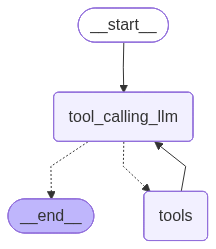

In [34]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
# Critical edge: after tools run, return to the LLM so it can use results
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [35]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ggk2sd5mp)
 Call ID: ggk2sd5mp
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (0p271jger)
 Call ID: 0p271jger
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/janakirammsv/2026/06/29/prompts-are-the-new-malware-as-enterprise-ai-defenses-fall-behind/", "title": "Prompts Are The New Malware As Enterprise AI Defenses Fall Behind - Forbes", "score": 0.57894874, "published_date": "Mon, 29 Jun 2026 00:00:00 GMT", "content": "# Prompts Are The New Malware As Enterprise AI Defenses Fall Behind. A recent Cro

### 6.6 Why Memory Still Fails Here

Even with a loop, **without a checkpointer** each `invoke()` starts fresh — the graph cannot recall your name on the next turn. Part C fixes this.

In [36]:
response=graph.invoke({"messages":"Hello my name is Mayank!"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hello my name is Mayank!
================================== Ai Message ==================================

Hello Mayank! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [37]:
response=graph.invoke({"messages":"What is my name?"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


## 7. Part C — Conversation Memory with `MemorySaver`

```python
graph = builder.compile(checkpointer=memory)
```

- **`MemorySaver`** stores graph state in RAM keyed by `thread_id`.
- Reuse the **same `thread_id`** across `invoke()` calls to continue a conversation.
- Production apps often swap in Redis/Postgres checkpointers.

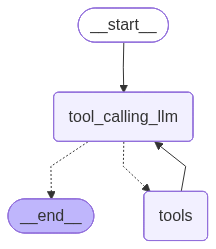

In [41]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# In-memory checkpointer persists state per thread_id (good for demos)
memory = MemorySaver()


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

# checkpointer=memory enables multi-turn recall within the same thread_id
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


### 7.1 Test Multi-Turn Memory

1. Tell the bot your name (`thread_id="1"`).
2. Ask *"What is my name?"* in a **new** `invoke()` with the **same** config.
3. Compare with a **different** `thread_id` — memory should not carry over.

In [42]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hi my name is Mayank"}, config=config)

response

{'messages': [HumanMessage(content='Hi my name is Mayank', additional_kwargs={}, response_metadata={}, id='48b2dc53-2b1f-4519-84e2-310ffc5e82c8'),
  AIMessage(content="Hello Mayank! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.075415832, 'completion_tokens_details': None, 'prompt_time': 0.144053172, 'prompt_tokens_details': None, 'queue_time': 0.04144068, 'total_time': 0.219469004}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f13f3-3443-7e62-bcb9-cba0e486f76d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778})]}

In [43]:
response["messages"][-1].content

"Hello Mayank! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [46]:
# Follow-up in the SAME thread — the model should recall the name from checkpoint
response = graph.invoke({"messages": "What is my name?"}, config=config)
print(response["messages"][-1].content)


Hello Mayank! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [48]:
response=graph.invoke({"messages":"Hey do you remember my name?"}, config=config)
print(response["messages"][-1].content)

Yes, I remember your name is Mayank.


## 8. Part D — Simple Checkpointed Bot & Streaming Modes

A single-node **SuperBot** graph demonstrates persistence and streaming without tools.

In [49]:
# Fresh MemorySaver for the simpler single-node demo below
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [67]:
def superbot(state: State):
    """Minimal node: no tools, just LLM chat with checkpointed history."""
    return {"messages": llm.invoke(state["messages"])}


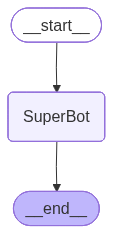

In [72]:
graph = StateGraph(State)
graph.add_node("SuperBot", superbot)
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [73]:
config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi,My name is Mayank and I like cricket"}, config)

{'messages': [HumanMessage(content='Hi my name is Mayank', additional_kwargs={}, response_metadata={}, id='f5c7413e-4572-4414-b3cb-f157e84930ab'),
  HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='60434d1b-d2aa-4fd4-a4e5-c905bbef1537'),
  HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='70cd91e9-c9a9-4775-b73f-79687e20bc94'),
  HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='7b2241c6-4004-417b-a4d4-cb24c1957d3e'),
  HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='643f6c9a-a9ba-4893-91bb-dbe149568ff7'),
  HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='4c1fb5ea-9466-4af7-99bc-10ed431e2a71'),
  HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs=

### 8.1 `stream_mode` Comparison

| Mode | You get |
|------|---------|
| `"updates"` | Only what each node **changed** |
| `"values"` | **Full state** after every step |

Send a follow-up message with the same `thread_id` to see history accumulate.

In [76]:
# stream_mode='updates' — only the delta each node produced
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi,My name is Mayank and I like cricket"}, config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': AIMessage(content="Hello again, Mayank. We already started talking about cricket. What's your favorite aspect of the game? Is it the thrill of a Test match, the excitement of a T20, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 115, 'total_tokens': 158, 'completion_time': 0.129862088, 'completion_tokens_details': None, 'prompt_time': 0.015361223, 'prompt_tokens_details': None, 'queue_time': 0.051617602, 'total_time': 0.145223311}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f140e-e82f-7703-bd5b-d3b72e55c3eb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 115, 'output_tokens': 43, 'total_tokens': 158})}}


In [77]:
# stream_mode='values' — full accumulated state after each step
for chunk in graph_builder.stream({"messages": "Hi,My name is Mayank and I like cricket"}, config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='dc50e52f-4a3c-49a8-bfd9-335d8dd30f42'), AIMessage(content='Nice to meet you, Mayank. Cricket is an exciting sport, and there are many passionate fans around the world. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.156468005, 'completion_tokens_details': None, 'prompt_time': 0.022168975, 'prompt_tokens_details': None, 'queue_time': 0.296613303, 'total_time': 0.17863698}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f140e-6874-7c10-813f-f11910f80b6f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

In [79]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Mayank And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': AIMessage(content="Hi Mayank, we've already established that you like cricket. Let's dive deeper into the game. What format of cricket do you enjoy the most: Test, ODI, or T20? And do you have a favorite cricket stadium or a memorable match that you've watched?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 321, 'total_tokens': 379, 'completion_time': 0.215955546, 'completion_tokens_details': None, 'prompt_time': 0.017729485, 'prompt_tokens_details': None, 'queue_time': 0.493817476, 'total_time': 0.233685031}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1410-be7d-7d60-b353-024d14e09d09-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 321, 'output_tokens': 58, 'total_tokens': 379})}}


In [80]:
# Same thread_id — new message appends to prior checkpointed conversation
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Mayank and I like cricket', additional_kwargs={}, response_metadata={}, id='dc50e52f-4a3c-49a8-bfd9-335d8dd30f42'), AIMessage(content='Nice to meet you, Mayank. Cricket is an exciting sport, and there are many passionate fans around the world. Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 46, 'total_tokens': 95, 'completion_time': 0.156468005, 'completion_tokens_details': None, 'prompt_time': 0.022168975, 'prompt_tokens_details': None, 'queue_time': 0.296613303, 'total_time': 0.17863698}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f140e-6874-7c10-813f-f11910f80b6f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

### 8.2 Async Event Stream (`astream_events`)

`astream_events(..., version="v2")` exposes low-level events — token chunks, tool start/end — ideal for building production chat interfaces.

---

## Key Takeaways

1. **State + reducers** keep conversation history consistent across nodes.
2. **Conditional edges** route between LLM and tools dynamically.
3. **The tool loop edge** (`tools → LLM`) is required for grounded answers.
4. **Checkpointer + thread_id** = durable multi-turn sessions.
5. **Streaming APIs** let you build responsive agent UIs.

## Next Steps

- Swap `MemorySaver` for a persistent checkpointer (SQLite, Postgres).
- Add human-in-the-loop approval before tool execution.
- Explore [LangGraph Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/) for visual debugging.

In [81]:
# astream_events (v2) exposes fine-grained tokens, tool starts, etc.
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Mayank and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Mayank and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f1411-40bd-73d3-9329-5cfac46d871f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Mayank and I like to play cricket', additional_kwargs={}, response_metadata={}, id='5ed42d09-0db6-40d0-80a5-ec4ba985c2ef')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f1411-40c2-7c23-8f3b-d1e4aad4f34a', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:3a608be1-3ab5-43c0-8325-24c9efb22823'}, 'parent_ids': ['019f1411-40bd-73d3-9329-5cfac46d871f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages